In [ ]:
from google.colab import files
import numpy as np
import pandas as pd

In [ ]:
uploaded = files.upload()

Saving data.csv to data (2).csv


EDA

In [ ]:
df = pd.read_csv('data.csv')

In [ ]:
df.columns

Index(['id', 'target', 'comment_text', 'severe_toxicity', 'obscene',
       'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual',
       'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu',
       'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability',
       'jewish', 'latino', 'male', 'muslim', 'other_disability',
       'other_gender', 'other_race_or_ethnicity', 'other_religion',
       'other_sexual_orientation', 'physical_disability',
       'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'sexual_explicit',
       'identity_annotator_count', 'toxicity_annotator_count'],
      dtype='object')

In [ ]:
df.head()

,id,target,comment_text,severe_toxicity,obscene,identity_attack,insult,threat,asian,atheist,...,article_id,rating,funny,wow,sad,likes,disagree,sexual_explicit,identity_annotator_count,toxicity_annotator_count
0,59856,0.893617,haha you guys are a bunch of losers.,0.021277,0.000000,0.021277,0.872340,0.0000,0.0,0.0,...,2006,rejected,0,0,0,1,0,0.000000,4,47
1,239607,0.912500,Yet call out all Muslims for the acts of a few...,0.050000,0.237500,0.612500,0.887500,0.1125,0.0,0.0,...,26670,approved,0,0,0,1,0,0.000000,4,80
2,239612,0.830769,This bitch is nuts. Who would read a book by a...,0.107692,0.661538,0.338462,0.830769,0.0000,0.0,0.0,...,26674,rejected,0,0,0,0,0,0.061538,4,65
3,240311,0.968750,You're an idiot.,0.031250,0.062500,0.000000,0.968750,0.0000,NaN,NaN,...,32846,rejected,0,0,0,0,0,0.000000,0,32
4,240329,0.900000,Who cares!? Stark trek and Star Wars fans are ...,0.100000,0.200000,0.000000,0.900000,0.0000,NaN,NaN,...,32846,rejected,0,0,0,0,0,0.300000,0,10


In [ ]:
# Colab cell 1 — Install required packages
# Run this cell first. Some packages (aif360) are optional and heavy; below I keep to commonly available libs.
!pip install -q xgboost shap scikit-learn==1.2.2 category_encoders matplotlib seaborn nltk

# Optional (use only if you want advanced fairness libs and have the time)
# !pip install -q aif360  # often requires extra system deps, skip for simplicity



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 37.1 MB/s eta 0:00:00
  Installing build dependencies ... canceled
ERROR: Operation cancelled by user


In [ ]:
# Colab cell 2 — Imports and basic config
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import shap
import joblib
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set(style='whitegrid')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEP 1 — Create binary toxicity label

In [ ]:
df["toxicity_binary"] = (df["target"] >= 0.5).astype(int)
df["toxicity_binary"].value_counts()


,count
toxicity_binary,
1,45451
0,45451


STEP 2 — Quick EDA: Check bias across identity groups

In [ ]:
identity_columns = [
    'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female',
    'heterosexual', 'hindu', 'homosexual_gay_or_lesbian',
    'intellectual_or_learning_disability', 'jewish', 'latino', 'male',
    'muslim', 'other_disability', 'other_gender',
    'other_race_or_ethnicity', 'other_religion', 'other_sexual_orientation',
    'physical_disability', 'psychiatric_or_mental_illness', 'transgender',
    'white'
]

bias_summary = (
    df[["target"] + identity_columns]
    .groupby(identity_columns)
    .mean()
    .sort_values("target", ascending=False)
)

df[identity_columns].sum().sort_values(ascending=False).head()


,0
female,2742.082051
male,2479.492425
white,1614.564122
christian,1500.489243
muslim,1325.213836


STEP 3 — Train/test split for classification

In [ ]:
from sklearn.model_selection import train_test_split

feature_cols = identity_columns  # initial simple model

X = df[feature_cols].fillna(0)
y = df["toxicity_binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


STEP 4 — Logistic Regression baseline

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5441394862768825
              precision    recall  f1-score   support

           0       0.52      0.94      0.67      9091
           1       0.72      0.15      0.24      9090

    accuracy                           0.54     18181
   macro avg       0.62      0.54      0.46     18181
weighted avg       0.62      0.54      0.46     18181



STEP 5 — Bias/Fairness metrics

In [ ]:
import numpy as np

def demographic_parity_diff(feature):
    privileged = X_test[feature] > 0
    unprivileged = X_test[feature] == 0

    p1 = y_pred[privileged].mean()
    p0 = y_pred[unprivileged].mean()

    return p1 - p0

for col in identity_columns:
    print(col, demographic_parity_diff(col))


asian 0.1284835175099805
atheist 0.6263861145737901
bisexual 0.7156406559583658
black 0.8799268375116801
buddhist 0.7319303071985328
christian 0.12741541803271283
female 0.7486653109843361
heterosexual 0.5919328714500139
hindu 0.39870630333058077
homosexual_gay_or_lesbian 0.847328344536608
intellectual_or_learning_disability 0.8646601016518425
jewish 0.7080234690928148
latino 0.33241625591815677
male 0.7145558612296526
muslim 0.837240410506945
other_disability 0.5245093985998567
other_gender 0.49917910858905845
other_race_or_ethnicity 0.4890390369630415
other_religion 0.43638124651008886
other_sexual_orientation 0.6291832110884391
physical_disability 0.45481154894216347
psychiatric_or_mental_illness 0.8748247358271808
transgender 0.8144900330311875
white 0.8957654744709327


STEP 6 — SHAP to explain model behavior

/tmp/ipython-input-3259300174.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


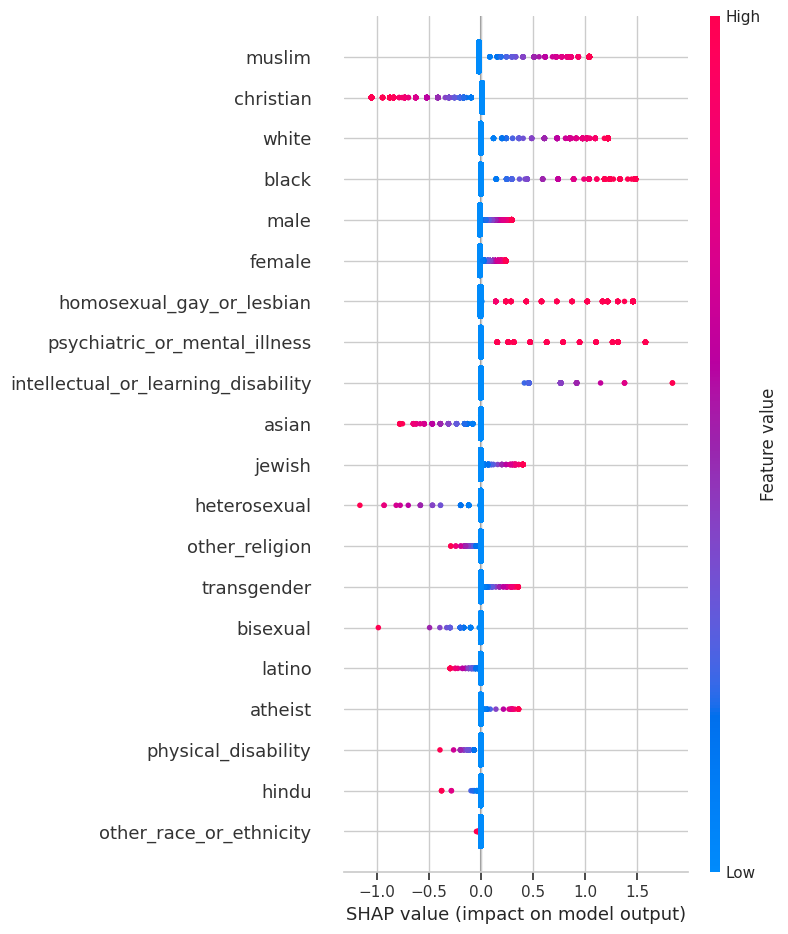

In [ ]:
import shap

explainer = shap.LinearExplainer(logreg, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


Comparisons

STEP 1 — Train Random Forest + Evaluate Fairness

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Train Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

# --- Model Accuracy ---
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.5449095209284418


STEP 2 — Train XGBoost + Evaluate Fairness

In [ ]:
!pip install xgboost


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Accuracy
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", xgb_acc)


XGBoost Accuracy: 0.5452945382542215


STEP 3 — Fairness Metrics for Each Model

In [ ]:
import numpy as np

def fairness_metrics(y_true, y_pred, y_proba, group):
    g = df_test[group]  # group membership 0/1

    # Demographic Parity
    dp = y_pred[g==1].mean() - y_pred[g==0].mean()

    # Equal Opportunity Difference (TPR gap)
    eod = (
        y_proba[(g==1) & (y_true==1)].mean()
        -
        y_proba[(g==0) & (y_true==1)].mean()
    )

    # False Positives
    fp_gap = (
        y_pred[(g==1) & (y_true==0)].mean()
        -
        y_pred[(g==0) & (y_true==0)].mean()
    )

    # False Negatives
    fn_gap = (
        (1 - y_pred[(g==1) & (y_true==1)]).mean()
        -
        (1 - y_pred[(g==0) & (y_true==1)]).mean()
    )

    return dp, eod, fp_gap, fn_gap


# Prepare df_test for group membership
df_test = df.iloc[y_test.index]

# Example fairness for "muslim"
groups = ["male", "female", "black", "muslim", "christian", "white"]

results = []
for grp in groups:
    dp_rf, eod_rf, fp_rf, fn_rf = fairness_metrics(y_test, rf_pred, rf_proba, grp)
    dp_xgb, eod_xgb, fp_xgb, fn_xgb = fairness_metrics(y_test, xgb_pred, xgb_proba, grp)

    results.append([grp, dp_rf, dp_xgb, eod_rf, eod_xgb, fp_rf, fp_xgb, fn_rf, fn_xgb])

fairness_results = pd.DataFrame(results, columns=[
    "Group",
    "DP_RF","DP_XGB",
    "EOD_RF","EOD_XGB",
    "FP_RF","FP_XGB",
    "FN_RF","FN_XGB"
])

fairness_results


,Group,DP_RF,DP_XGB,EOD_RF,EOD_XGB,FP_RF,FP_XGB,FN_RF,FN_XGB
0,male,0.321988,0.317185,0.064668,0.065712,0.257874,0.312582,-0.305431,-0.272602
1,female,0.364314,0.366902,0.028074,0.028515,0.423710,0.457230,-0.309587,-0.290773
2,black,0.599012,0.586718,0.301762,0.305510,0.731310,0.737493,-0.495376,-0.479163
3,muslim,0.571121,0.574618,0.171577,0.177776,0.690970,0.721337,-0.471675,-0.463980
4,christian,-0.215394,-0.205226,-0.125316,-0.131146,-0.228394,-0.198123,0.166812,0.174291
5,white,0.601294,0.604622,0.247503,0.247229,0.741733,0.748575,-0.499514,-0.499978


STEP 4 — SHAP Interpretability (RF & XGB)

In [ ]:
!pip install shap
import shap
shap.initjs()


SHAP for Random Forest

SHAP for XGBoost

In [ ]:
# ============================
# RANDOM FOREST INTERPRETATION
# USING FEATURE IMPORTANCES
# ============================

import numpy as np
import pandas as pd

# Get feature importances
rf_importances = rf.feature_importances_

# Create DataFrame
rf_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False)

# Show top 25 most important features
rf_importance_df.head(25)


/tmp/ipython-input-1726134748.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, X_test)


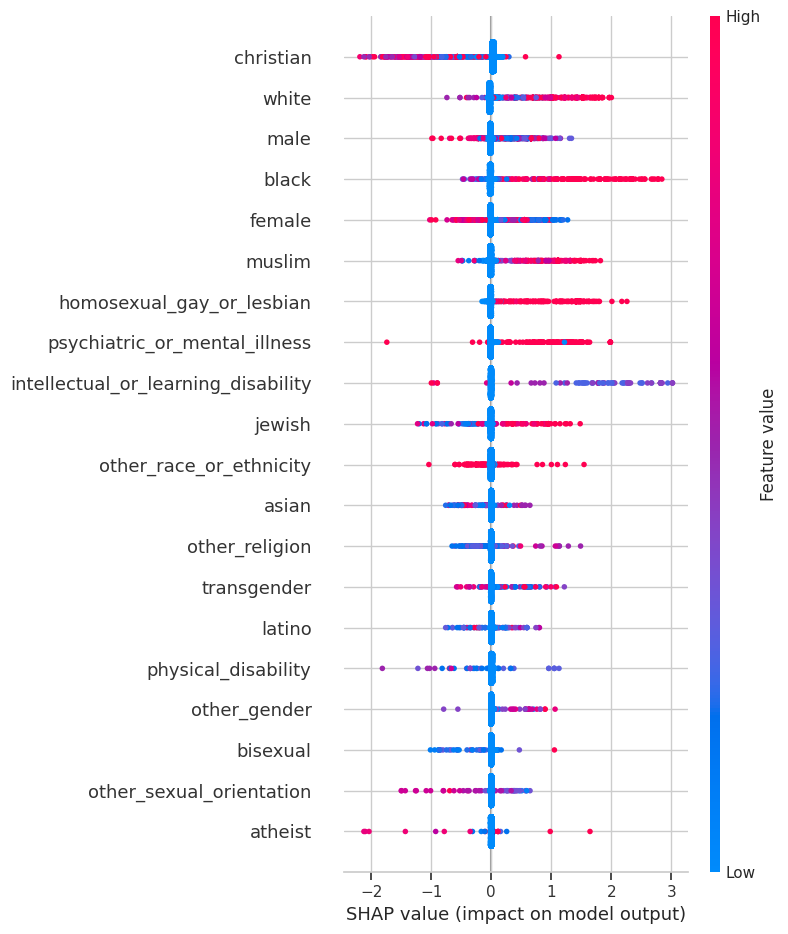

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test)


STEP 5 — Final Model Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [log_reg_acc, rf_acc, xgb_acc],
})

comparison


NameError: name 'log_reg_acc' is not defined